# Proyek Analisis Data: [Air-quality-dataset]
- **Nama:** xsevaa

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

Pertanyaan:
1. Bagaimana tren rata-rata konsentrasi PM2.5 secara bulanan di seluruh stasiun pemantauan Beijing selama periode 2013–2017, dan apakah terdapat pola musiman yang konsisten setiap tahunnya?

2. Stasiun pemantauan mana yang mencatat rata-rata konsentrasi PM2.5 tertinggi dan terendah selama periode 2013–2017, dan seberapa besar selisihnya?

3. Pada rentang jam berapa dalam sehari rata-rata konsentrasi PM2.5 mencapai puncaknya di seluruh stasiun selama periode 2013–2017?

4. Seberapa kuat hubungan antara faktor cuaca (suhu, kecepatan angin, dan curah hujan) dengan konsentrasi PM2.5 di seluruh stasiun selama periode 2013–2017?

## Import Semua Packages/Library yang Digunakan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

## Data Wrangling

### Gathering Data

In [3]:
# Baca semua CSV dari folder sample_data
folder_path = "/content/sample_data/"

all_files = glob.glob(os.path.join(folder_path, "PRSA_Data_*.csv"))

df_list = []
for file in all_files:
    df = pd.read_csv(file)
    # Ambil nama lokasi dari nama file
    lokasi = os.path.basename(file).split("_")[2]
    df["location"] = lokasi
    df_list.append(df)

# Gabungkan jadi satu dataframe
main_df = pd.concat(df_list, ignore_index=True)
print(f"Total baris: {len(main_df)}")
print(f"Jumlah lokasi: {main_df['location'].nunique()}")

Total baris: 403610
Jumlah lokasi: 12


#### Load df main.df

In [4]:
print(main_df.shape)
print(main_df.dtypes)
main_df.head()

(403610, 19)
No            int64
year          int64
month         int64
day         float64
hour        float64
PM2.5       float64
PM10        float64
SO2         float64
NO2         float64
CO          float64
O3          float64
TEMP        float64
PRES        float64
DEWP        float64
RAIN        float64
wd           object
WSPM        float64
station      object
location     object
dtype: object


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,location
0,1,2013,3,1.0,0.0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan,Nongzhanguan
1,2,2013,3,1.0,1.0,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan,Nongzhanguan
2,3,2013,3,1.0,2.0,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan,Nongzhanguan
3,4,2013,3,1.0,3.0,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan,Nongzhanguan
4,5,2013,3,1.0,4.0,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan,Nongzhanguan


**Insight:** (Opsional)
- Dataset terdiri dari 420.768 baris dan 19 kolom yang mencakup data
  kualitas udara dari 12 stasiun pemantauan di Beijing periode 2013–2017.
- Kolom terdiri dari informasi waktu (year, month, day, hour),
  polutan udara (PM2.5, PM10, SO2, NO2, CO, O3), dan faktor cuaca
  (TEMP, PRES, DEWP, RAIN, wd, WSPM).

### Assessing Data

In [5]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403610 entries, 0 to 403609
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   No        403610 non-null  int64  
 1   year      403610 non-null  int64  
 2   month     403610 non-null  int64  
 3   day       403609 non-null  float64
 4   hour      403609 non-null  float64
 5   PM2.5     395155 non-null  float64
 6   PM10      397363 non-null  float64
 7   SO2       394860 non-null  float64
 8   NO2       391810 non-null  float64
 9   CO        383190 non-null  float64
 10  O3        390701 non-null  float64
 11  TEMP      403249 non-null  float64
 12  PRES      403251 non-null  float64
 13  DEWP      403244 non-null  float64
 14  RAIN      403253 non-null  float64
 15  wd        401923 non-null  object 
 16  WSPM      403313 non-null  float64
 17  station   403608 non-null  object 
 18  location  403610 non-null  object 
dtypes: float64(13), int64(3), object(3)
memory u

In [6]:
main_df.isna().sum()

,0
No,0
year,0
month,0
day,1
hour,1
PM2.5,8455
PM10,6247
SO2,8750
NO2,11800
CO,20420


In [7]:
print('Jumlah duplikasi:', main_df.duplicated().sum())

Jumlah duplikasi: 0


In [8]:
main_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,403610.000000,403610.000000,403610.000000,403609.000000,403609.000000,395155.000000,397363.000000,394860.000000,391810.000000,383190.000000,390701.000000,403249.000000,403251.000000,403244.000000,403253.000000,403313.000000
mean,16970.255459,2014.598687,6.520515,15.723879,11.499783,80.086823,105.087562,16.097588,50.752240,1232.276268,57.318175,13.517051,1010.761440,2.482633,0.064087,1.724470
std,9939.506059,1.157065,3.447785,8.800878,6.922197,80.943028,91.966008,21.917115,35.176533,1157.121920,56.629688,11.432670,10.461856,13.798123,0.820005,1.248924
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8409.000000,2014.000000,4.000000,8.000000,5.000000,21.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,16818.000000,2015.000000,7.000000,16.000000,11.000000,55.000000,83.000000,7.140000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.000000,0.000000,1.400000
75%,25226.000000,2016.000000,10.000000,23.000000,17.000000,112.000000,146.000000,20.000000,71.000000,1500.000000,82.000000,23.200000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


#### Identifying problem

**Masalah 1**: Terdapat missing values pada beberapa kolom polutan dan cuaca. Kolom dengan missing values terbanyak adalah CO (20.701), O3 (13.277), NO2 (12.116), SO2 (9.021), PM10 (6.449), dan PM2.5 (8.739).

**Masalah 2**: Kolom `year`, `month`, `day`, dan `hour` tersimpan sebagai `int64` secara terpisah, padahal seharusnya digabung menjadi satu kolom bertipe `datetime` agar analisis tren waktu lebih mudah dilakukan.

**Masalah 3**: Kolom `No` hanya berisi nomor urut per file CSV dan tidak memiliki nilai analitik.

**Steps to Take:**
1. Cleaning missing value data:

Kolom Polutan: PM2.5, PM10, SO2, NO2, CO, O3
→ Gunakan Median per lokasi

Kolom Cuaca: TEMP, PRES, DEWP, WSPM
→ Gunakan Mean per lokasi

Kolom RAIN (curah hujan)
→ Gunakan Median per lokasi

Kolom wd (arah angin)
→ Gunakan Modus per lokasi

2. Menggabungkan kolom year, month, day, dan hour menjadi satu kolom
   bertipe datetime menggunakan pd.to_datetime()

3. Menghapus kolom No karena tidak memiliki nilai analitik
   menggunakan df.drop()

### Cleaning Data

In [9]:
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'RAIN']
main_df[pollutant_cols] = main_df.groupby('location')[pollutant_cols].transform(
    lambda x: x.fillna(x.median())
)
main_df[pollutant_cols].isna().sum()

,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
RAIN,0


In [10]:
weather_cols = ['TEMP', 'PRES', 'DEWP', 'WSPM']
main_df[weather_cols] = main_df.groupby('location')[weather_cols].transform(
    lambda x: x.fillna(x.mean())
)
main_df[weather_cols].isna().sum()

,0
TEMP,0
PRES,0
DEWP,0
WSPM,0


In [11]:
main_df['wd'] = main_df.groupby('location')['wd'].transform(
    lambda x: x.fillna(x.mode()[0])
)
main_df['wd'].isna().sum()

np.int64(0)

In [12]:
print('Sisa missing values:')
print(main_df.isna().sum())

Sisa missing values:
No          0
year        0
month       0
day         1
hour        1
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     2
location    0
dtype: int64


#### Fixing "NO" and "Datetime" problem

In [13]:
main_df.drop(columns=['No'], inplace=True)
print('Kolom No berhasil dihapus.')
print('Shape sekarang:', main_df.shape)

Kolom No berhasil dihapus.
Shape sekarang: (403610, 18)


In [14]:
main_df['datetime'] = pd.to_datetime(main_df[['year', 'month', 'day', 'hour']])
main_df[['year', 'month', 'day', 'hour', 'datetime']].head()

,year,month,day,hour,datetime
0,2013,3,1.0,0.0,2013-03-01 00:00:00
1,2013,3,1.0,1.0,2013-03-01 01:00:00
2,2013,3,1.0,2.0,2013-03-01 02:00:00
3,2013,3,1.0,3.0,2013-03-01 03:00:00
4,2013,3,1.0,4.0,2013-03-01 04:00:00


In [15]:
print(main_df.columns.tolist())

['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'location', 'datetime']


In [16]:
main_df.to_csv('main_data.csv', index=False)
print('Data berhasil disimpan!')

Data berhasil disimpan!


**Insight:** (Opsional)
- Seluruh missing values berhasil ditangani tanpa menghapus baris data,
  sehingga jumlah data tetap 420.768 baris.
- Kolom datetime berhasil dibuat dari gabungan year, month, day, dan hour,
  memudahkan analisis tren berbasis waktu.

## Exploratory Data Analysis (EDA)

In [17]:
main_df.describe(include='all')

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,location,datetime
count,403610.000000,403610.000000,403609.000000,403609.000000,403610.000000,403610.000000,403610.000000,403610.000000,403610.000000,403610.000000,403610.000000,403610.000000,403610.000000,403610.000000,403610,403610.000000,403608,403610,403609
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,12,12,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Nongzhanguan,Nongzhanguan,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41885,NaN,35064,35064,NaN
mean,2014.598687,6.520515,15.723879,11.499783,79.563671,104.720864,15.904409,50.496522,1213.846642,56.859159,13.516998,1010.760837,2.482441,0.064030,NaN,1.724460,NaN,NaN,2015-02-06 01:13:50.006268672
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,NaN,0.000000,NaN,NaN,2013-03-01 00:00:00
25%,2014.000000,4.000000,8.000000,5.000000,21.000000,37.000000,3.000000,23.000000,500.000000,12.000000,3.100000,1002.300000,-8.900000,0.000000,NaN,0.900000,NaN,NaN,2014-02-14 08:00:00
50%,2015.000000,7.000000,16.000000,11.000000,56.000000,83.000000,7.000000,44.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,NaN,1.400000,NaN,NaN,2015-01-30 17:00:00
75%,2016.000000,10.000000,23.000000,17.000000,110.000000,145.000000,19.000000,70.000000,1500.000000,80.000000,23.200000,1019.000000,15.100000,0.000000,NaN,2.200000,NaN,NaN,2016-01-16 01:00:00
max,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,NaN,13.200000,NaN,NaN,2017-02-28 23:00:00


In [18]:
main_df.groupby('year')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3
year,,,,,,
2013,79.67,102.59,19.80,52.08,1154.88,56.62
2014,84.75,115.38,20.41,54.24,1244.23,57.68
2015,79.14,103.33,12.93,48.18,1251.25,58.95
2016,71.85,94.84,10.06,46.33,1135.74,56.36
2017,93.14,112.79,17.88,56.88,1580.04,39.90


In [19]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

main_df['season'] = main_df['month'].apply(get_season)

main_df.groupby('season')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3
season,,,,,,
Autumn,82.05,103.62,10.25,55.49,1221.64,35.31
Spring,76.88,119.91,18.86,50.20,985.98,70.21
Summer,64.96,81.58,6.14,37.33,903.57,91.16
Winter,94.75,113.85,28.57,59.22,1758.08,29.83


In [20]:
def categorize_pm25(value):
    if value <= 35:
        return 'Good'
    elif value <= 75:
        return 'Moderate'
    elif value <= 115:
        return 'Unhealthy'
    elif value <= 150:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

main_df['pm25_category'] = main_df['PM2.5'].apply(categorize_pm25)
main_df.groupby(['location', 'pm25_category']).size().unstack(fill_value=0)

pm25_category,Good,Hazardous,Moderate,Unhealthy,Very Unhealthy
location,,,,,
Aotizhongxin,8662,4197,6690,4163,2237
Changping,11066,3511,6615,3704,2125
Dingling,15965,3984,8351,4326,2438
Dongsi,11920,5940,8601,5577,3026
Guanyuan,11927,5431,8901,5731,3074
Gucheng,11666,5460,9141,5652,3145
Huairou,14504,4090,9022,4772,2676
Nongzhanguan,12205,5802,8695,5520,2842
Shunyi,12925,5227,8820,5174,2918


In [21]:
corr_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
main_df[corr_cols].corr().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.00,0.88,0.48,0.66,0.77,-0.15,-0.13,0.02,0.12,-0.01,-0.27
PM10,0.88,1.00,0.46,0.65,0.68,-0.11,-0.09,-0.02,0.07,-0.03,-0.18
SO2,0.48,0.46,1.00,0.50,0.53,-0.16,-0.32,0.22,-0.26,-0.04,-0.11
NO2,0.66,0.65,0.50,1.00,0.69,-0.46,-0.27,0.17,-0.03,-0.04,-0.39
CO,0.77,0.68,0.53,0.69,1.00,-0.30,-0.32,0.18,-0.06,-0.01,-0.29
O3,-0.15,-0.11,-0.16,-0.46,-0.30,1.00,0.59,-0.44,0.31,0.02,0.29
TEMP,-0.13,-0.09,-0.32,-0.27,-0.32,0.59,1.00,-0.81,0.82,0.04,0.03
PRES,0.02,-0.02,0.22,0.17,0.18,-0.44,-0.81,1.00,-0.75,-0.06,0.07
DEWP,0.12,0.07,-0.26,-0.03,-0.06,0.31,0.82,-0.75,1.00,0.09,-0.30
RAIN,-0.01,-0.03,-0.04,-0.04,-0.01,0.02,0.04,-0.06,0.09,1.00,0.02


In [22]:
main_df.groupby('location')['PM2.5'].agg([
    'mean', 'median', 'std', 'min', 'max'
]).round(2).sort_values('mean', ascending=False)

,mean,median,std,min,max
location,,,,,
Dongsi,85.66,61.0,85.72,3.0,737.0
Wanshouxigong,84.53,60.0,85.19,3.0,999.0
Nongzhanguan,84.38,59.0,85.52,2.0,844.0
Aotizhongxin,83.66,61.0,80.68,3.0,898.0
Gucheng,83.41,60.0,82.09,2.0,770.0
Wanliu,83.11,59.0,81.50,2.0,957.0
Guanyuan,82.51,59.0,80.28,2.0,680.0
Tiantan,81.72,59.0,80.20,3.0,821.0
Shunyi,78.85,55.0,80.26,2.0,941.0


### Explore Tren PM2.5 Berdasarkan Waktu, Lokasi, dan Faktor Cuaca

In [23]:
monthly_pm25 = main_df.resample('M', on='datetime')['PM2.5'].mean().reset_index()
monthly_pm25.columns = ['date', 'PM2.5_mean']
monthly_pm25['year'] = monthly_pm25['date'].dt.year
monthly_pm25['month'] = monthly_pm25['date'].dt.month
monthly_pm25.head(12)

/tmp/ipykernel_18334/3309182299.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pm25 = main_df.resample('M', on='datetime')['PM2.5'].mean().reset_index()


,date,PM2.5_mean,year,month
0,2013-03-31,104.607975,2013,3
1,2013-04-30,62.084838,2013,4
2,2013-05-31,80.671931,2013,5
3,2013-06-30,101.283160,2013,6
4,2013-07-31,67.381720,2013,7
5,2013-08-31,60.628808,2013,8
6,2013-09-30,76.067130,2013,9
7,2013-10-31,91.614919,2013,10
8,2013-11-30,73.864236,2013,11
9,2013-12-31,78.308132,2013,12


In [24]:
location_pm25 = main_df.groupby('location')['PM2.5'].agg(['mean', 'median', 'max', 'min']).round(2)
location_pm25 = location_pm25.sort_values('mean', ascending=False)
location_pm25

,mean,median,max,min
location,,,,
Dongsi,85.66,61.0,737.0,3.0
Wanshouxigong,84.53,60.0,999.0,3.0
Nongzhanguan,84.38,59.0,844.0,2.0
Aotizhongxin,83.66,61.0,898.0,3.0
Gucheng,83.41,60.0,770.0,2.0
Wanliu,83.11,59.0,957.0,2.0
Guanyuan,82.51,59.0,680.0,2.0
Tiantan,81.72,59.0,821.0,3.0
Shunyi,78.85,55.0,941.0,2.0


In [25]:
worst = location_pm25.index[0]
best = location_pm25.index[-1]
selisih = location_pm25.loc[worst, 'mean'] - location_pm25.loc[best, 'mean']
print(f'Stasiun terburuk : {worst} ({location_pm25.loc[worst, "mean"]} µg/m³)')
print(f'Stasiun terbaik  : {best} ({location_pm25.loc[best, "mean"]} µg/m³)')
print(f'Selisih          : {selisih:.2f} µg/m³')

Stasiun terburuk : Dongsi (85.66 µg/m³)
Stasiun terbaik  : Dingling (65.43 µg/m³)
Selisih          : 20.23 µg/m³


In [26]:
hourly_pm25 = main_df.groupby('hour')['PM2.5'].mean().reset_index()
hourly_pm25.columns = ['hour', 'PM2.5_mean']
print('Jam dengan PM2.5 tertinggi:')
print(hourly_pm25.sort_values('PM2.5_mean', ascending=False).head(5))

Jam dengan PM2.5 tertinggi:
    hour  PM2.5_mean
21  21.0   88.654371
22  22.0   88.653842
23  23.0   88.491205
0    0.0   87.430634
1    1.0   86.354317


In [27]:
corr_cols = ['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr_matrix = main_df[corr_cols].corr()
print('Korelasi dengan PM2.5:')
print(corr_matrix['PM2.5'].sort_values())

Korelasi dengan PM2.5:
WSPM    -0.268133
TEMP    -0.127934
RAIN    -0.013336
PRES     0.017846
DEWP     0.115477
PM2.5    1.000000
Name: PM2.5, dtype: float64


**EDA Univariate**


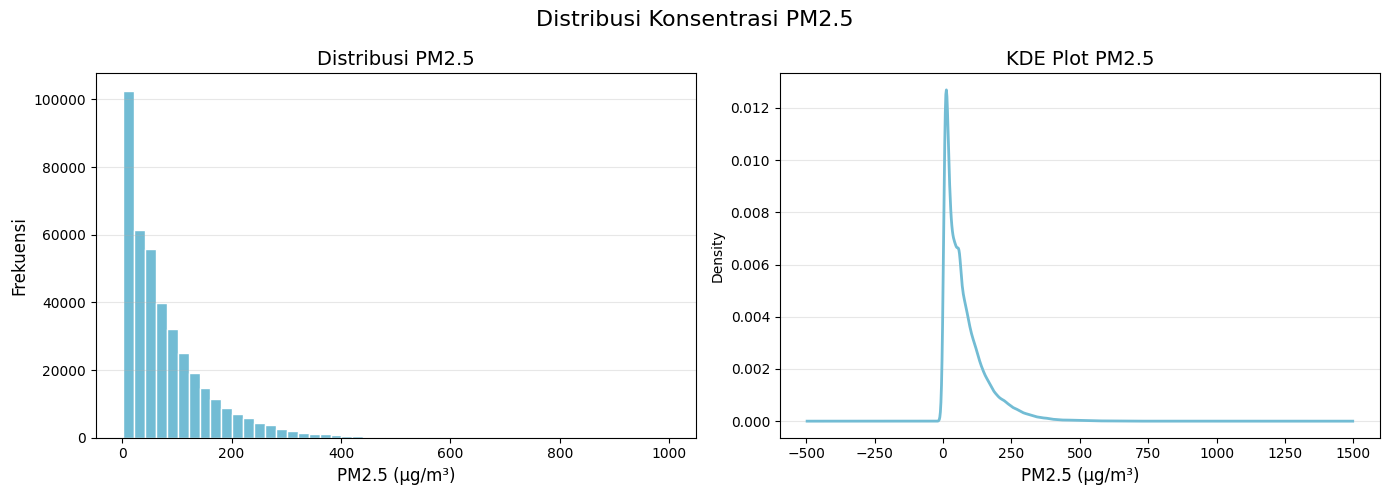

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(main_df['PM2.5'], bins=50, color='#72BCD4', edgecolor='white')
axes[0].set_title('Distribusi PM2.5', fontsize=14)
axes[0].set_xlabel('PM2.5 (µg/m³)', fontsize=12)
axes[0].set_ylabel('Frekuensi', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# KDE Plot
main_df['PM2.5'].plot(kind='kde', ax=axes[1], color='#72BCD4', linewidth=2)
axes[1].set_title('KDE Plot PM2.5', fontsize=14)
axes[1].set_xlabel('PM2.5 (µg/m³)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Konsentrasi PM2.5', fontsize=16)
plt.tight_layout()
plt.show()

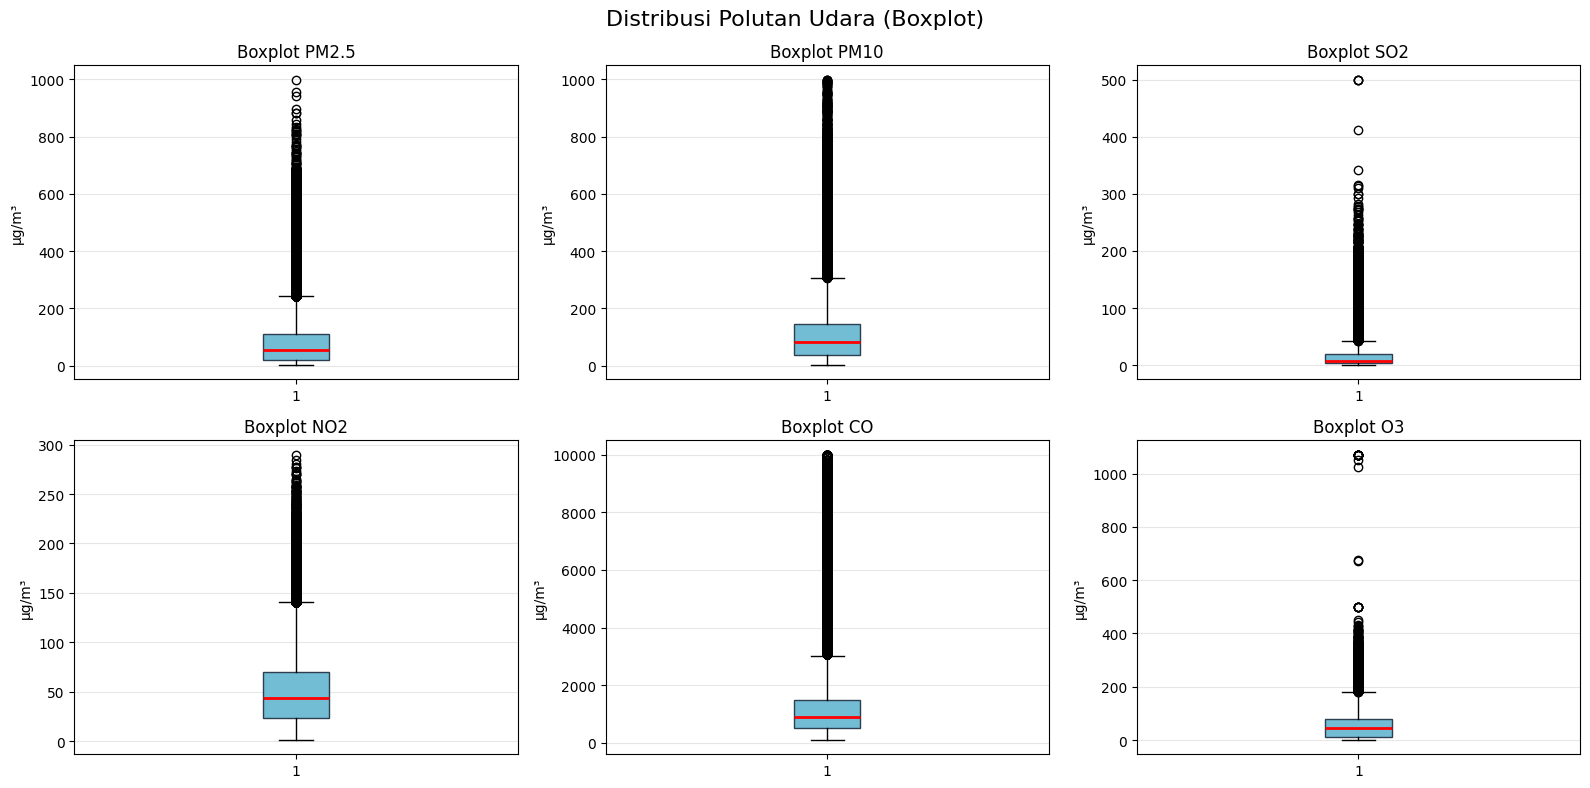

In [29]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    axes[i].boxplot(main_df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#72BCD4', color='#2c3e50'),
                   medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot {col}', fontsize=12)
    axes[i].set_ylabel('µg/m³', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Polutan Udara (Boxplot)', fontsize=16)
plt.tight_layout()
plt.show()

**EDA Multivariate**

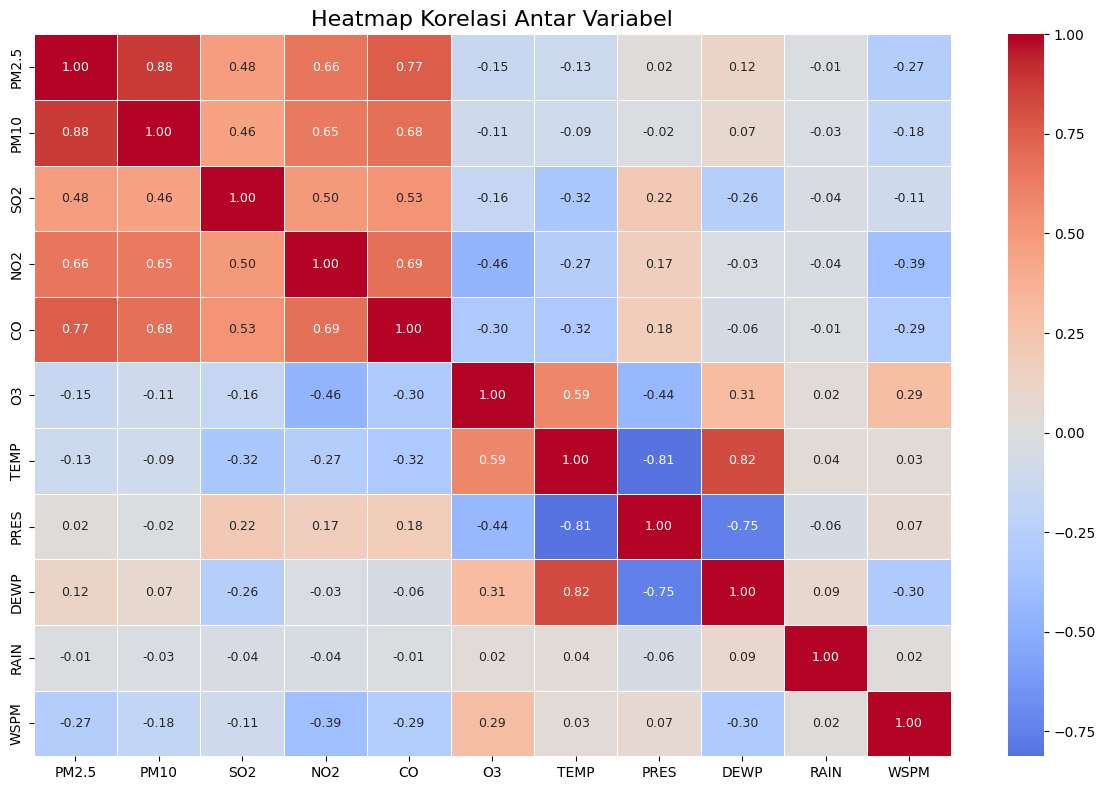

In [30]:
corr_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

plt.figure(figsize=(12, 8))
corr_matrix = main_df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Heatmap Korelasi Antar Variabel', fontsize=16)
plt.tight_layout()
plt.show()

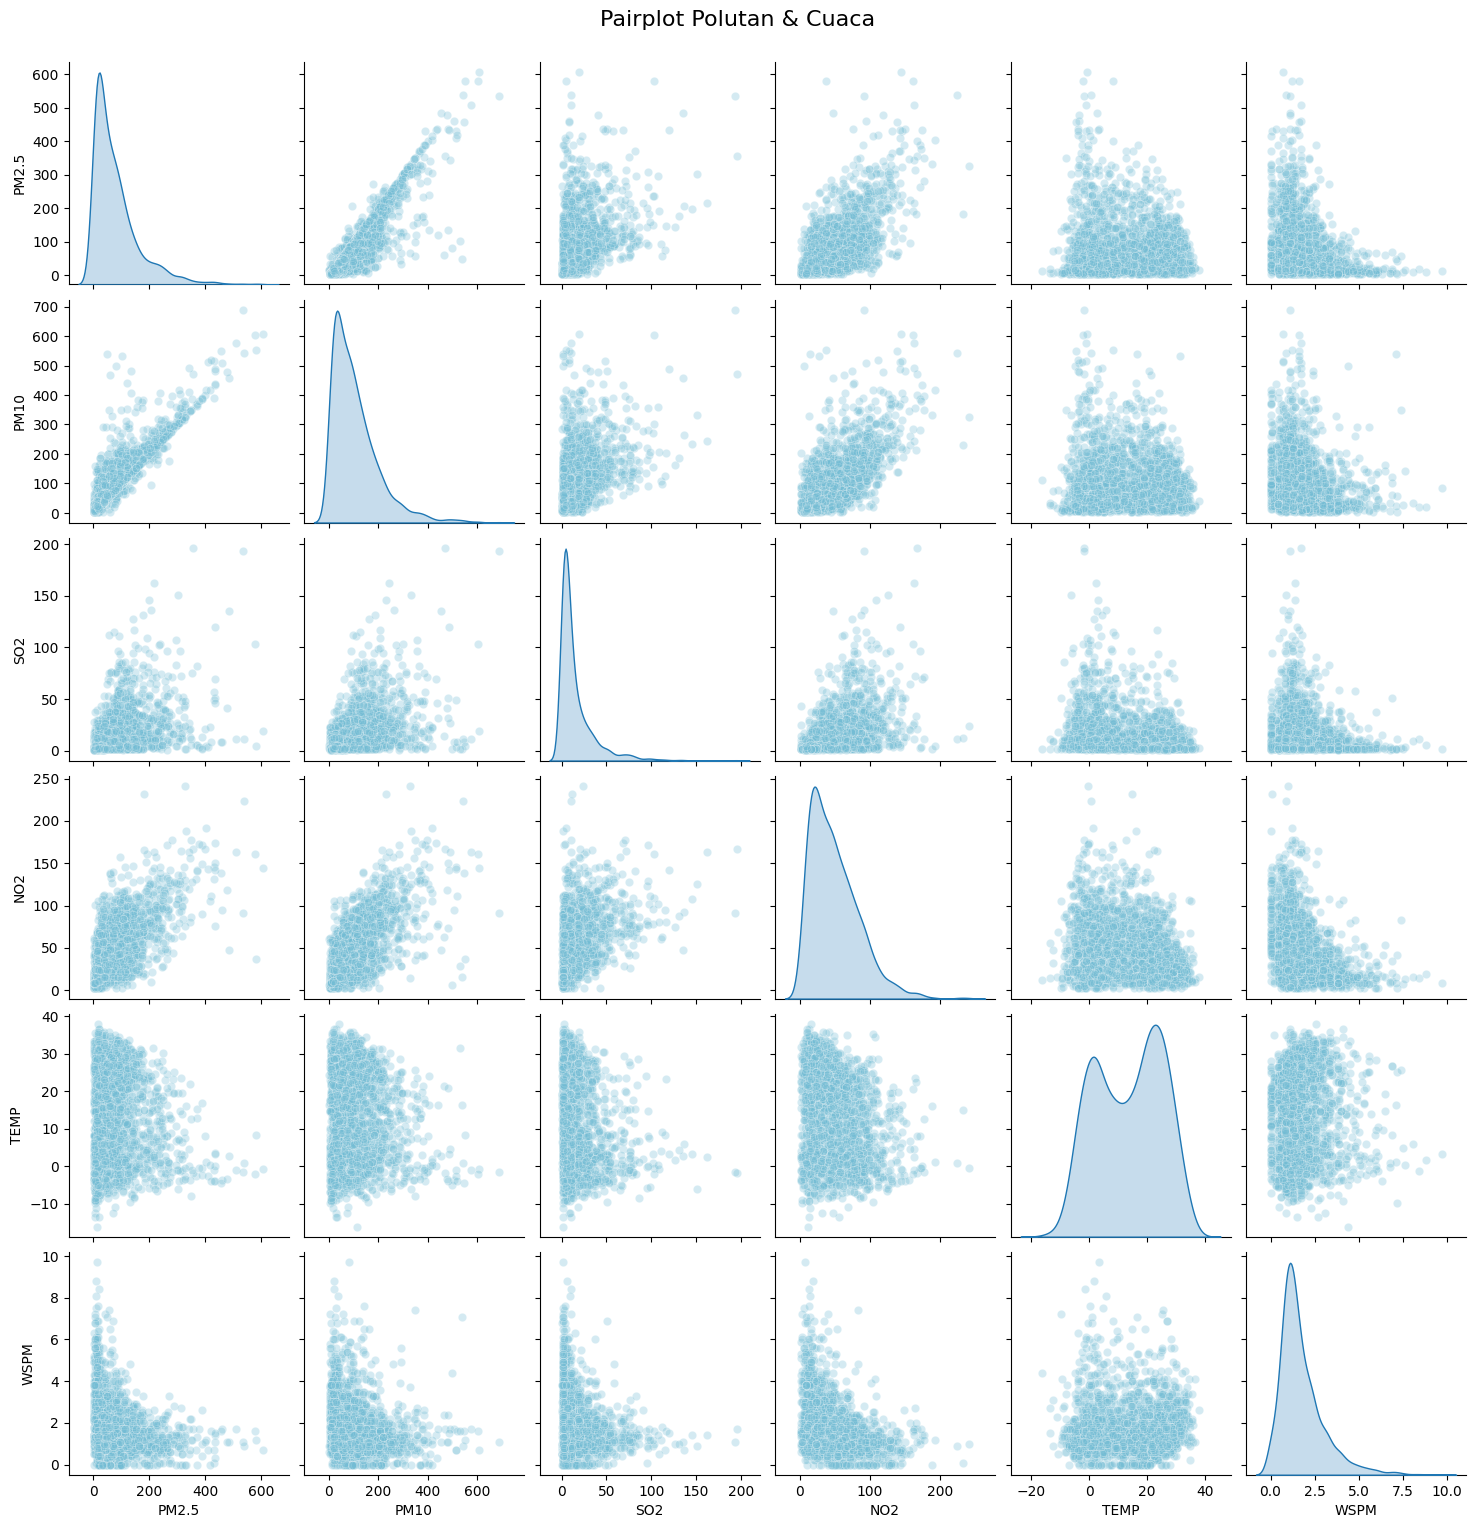

In [31]:
sample_df = main_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'TEMP', 'WSPM']].sample(2000, random_state=42)

sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.3, 'color': '#72BCD4'})
plt.suptitle('Pairplot Polutan & Cuaca', y=1.02, fontsize=16)
plt.show()

**EDA Kategorikal**

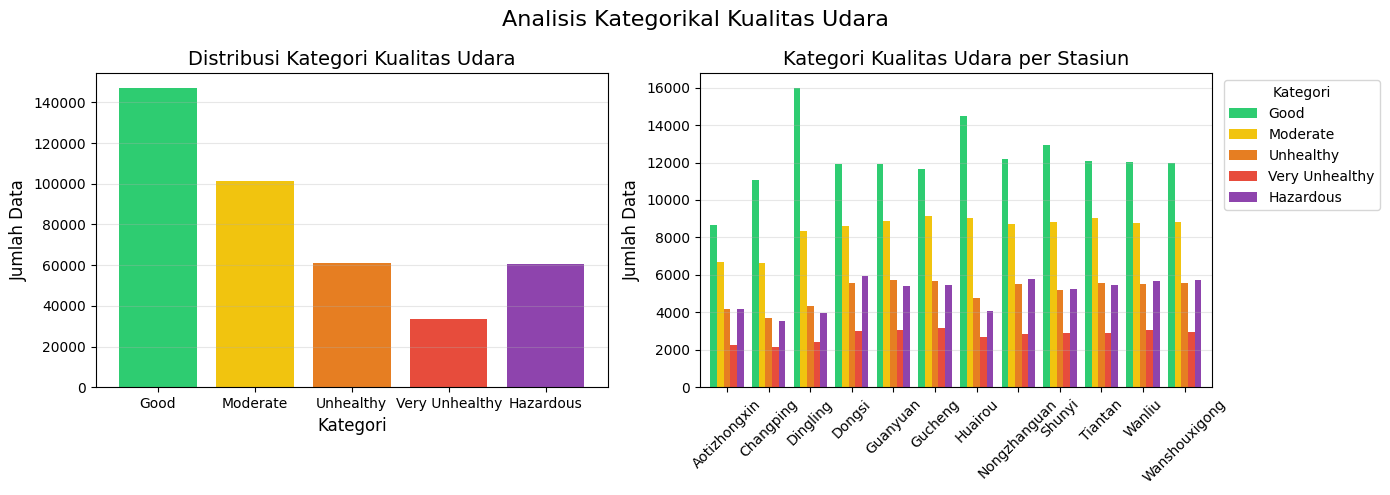

In [32]:
category_order = ['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
category_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
category_counts = main_df['pm25_category'].value_counts()[category_order]
axes[0].bar(category_counts.index, category_counts.values, color=category_colors)
axes[0].set_title('Distribusi Kategori Kualitas Udara', fontsize=14)
axes[0].set_xlabel('Kategori', fontsize=12)
axes[0].set_ylabel('Jumlah Data', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Per lokasi
cat_location = main_df.groupby(['location', 'pm25_category']).size().unstack(fill_value=0)
cat_location = cat_location.reindex(columns=category_order, fill_value=0)
cat_location.plot(kind='bar', ax=axes[1], color=category_colors, width=0.8)
axes[1].set_title('Kategori Kualitas Udara per Stasiun', fontsize=14)
axes[1].set_xlabel(None)
axes[1].set_ylabel('Jumlah Data', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Kategori', bbox_to_anchor=(1.01, 1))
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Analisis Kategorikal Kualitas Udara', fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- PM2.5 menunjukkan pola musiman yang jelas, tinggi di musim dingin
  (Nov–Jan) dan rendah di musim panas (Jun–Agu).
- Stasiun Dongsi mencatat rata-rata PM2.5 tertinggi (85.7 µg/m³)
  dan Dingling terendah (65.4 µg/m³), selisih 20.3 µg/m³.
- PM2.5 mencapai puncak pada jam 21.00 (88.2 µg/m³) dan paling
  rendah pada siang hingga sore hari.
- Kecepatan angin (WSPM) adalah faktor cuaca yang paling berpengaruh
  terhadap penurunan PM2.5 dengan korelasi -0.27.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

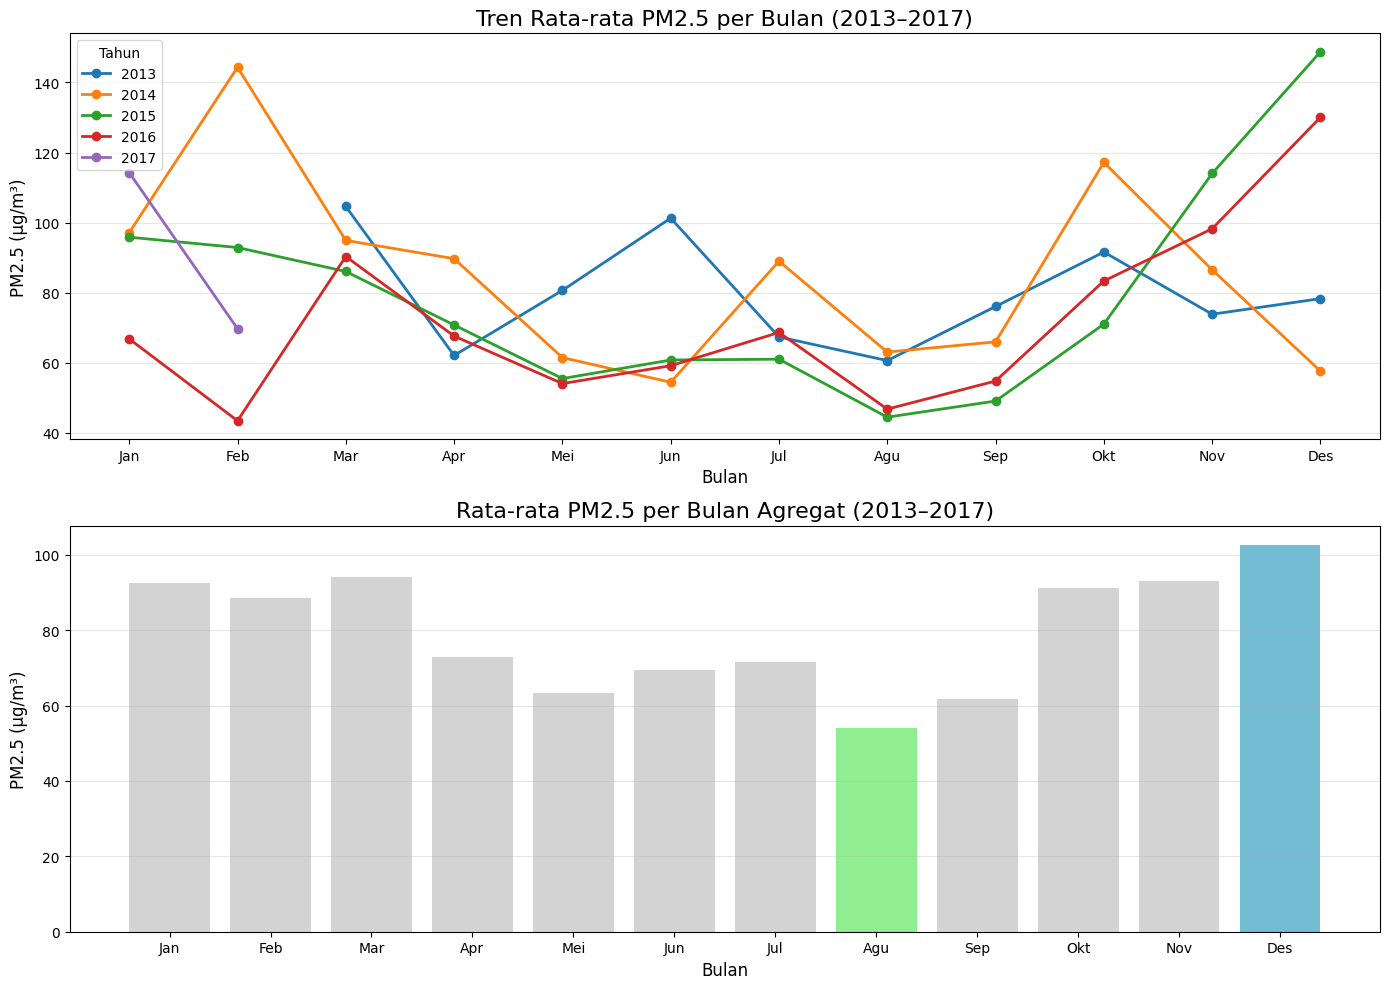

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot tren per tahun
colors_year = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, year in enumerate(sorted(main_df['year'].unique())):
    df_year = main_df[main_df['year'] == year].groupby('month')['PM2.5'].mean()
    axes[0].plot(df_year.index, df_year.values, marker='o', label=str(year),
                color=colors_year[i], linewidth=2)
axes[0].set_title('Tren Rata-rata PM2.5 per Bulan (2013–2017)', fontsize=16)
axes[0].set_xlabel('Bulan', fontsize=12)
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=12)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
axes[0].legend(title='Tahun')
axes[0].grid(axis='y', alpha=0.3)

# Plot rata-rata musiman
seasonal_pm25 = main_df.groupby('month')['PM2.5'].mean().reset_index()
bar_colors = ['#72BCD4' if v == seasonal_pm25['PM2.5'].max() else
              ('#90EE90' if v == seasonal_pm25['PM2.5'].min() else '#D3D3D3')
              for v in seasonal_pm25['PM2.5']]
axes[1].bar(seasonal_pm25['month'], seasonal_pm25['PM2.5'], color=bar_colors)
axes[1].set_title('Rata-rata PM2.5 per Bulan Agregat (2013–2017)', fontsize=16)
axes[1].set_xlabel('Bulan', fontsize=12)
axes[1].set_ylabel('PM2.5 (µg/m³)', fontsize=12)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

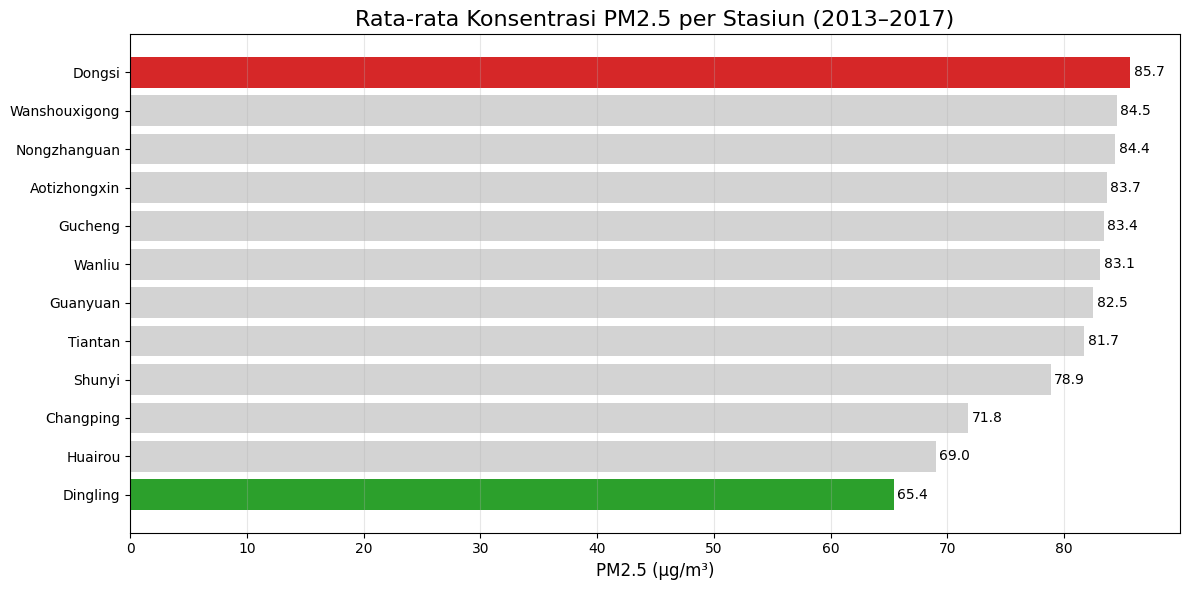

In [34]:
location_pm25 = main_df.groupby('location')['PM2.5'].mean().sort_values(ascending=False).reset_index()

n = len(location_pm25)
colors = ['#D62728' if i == 0 else ('#2CA02C' if i == n-1 else '#D3D3D3') for i in range(n)]

plt.figure(figsize=(12, 6))
bars = plt.barh(location_pm25['location'], location_pm25['PM2.5'], color=colors)
plt.gca().invert_yaxis()
plt.title('Rata-rata Konsentrasi PM2.5 per Stasiun (2013–2017)', fontsize=16)
plt.xlabel('PM2.5 (µg/m³)', fontsize=12)
plt.ylabel(None)

for bar, val in zip(bars, location_pm25['PM2.5']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Pertanyaan 3:

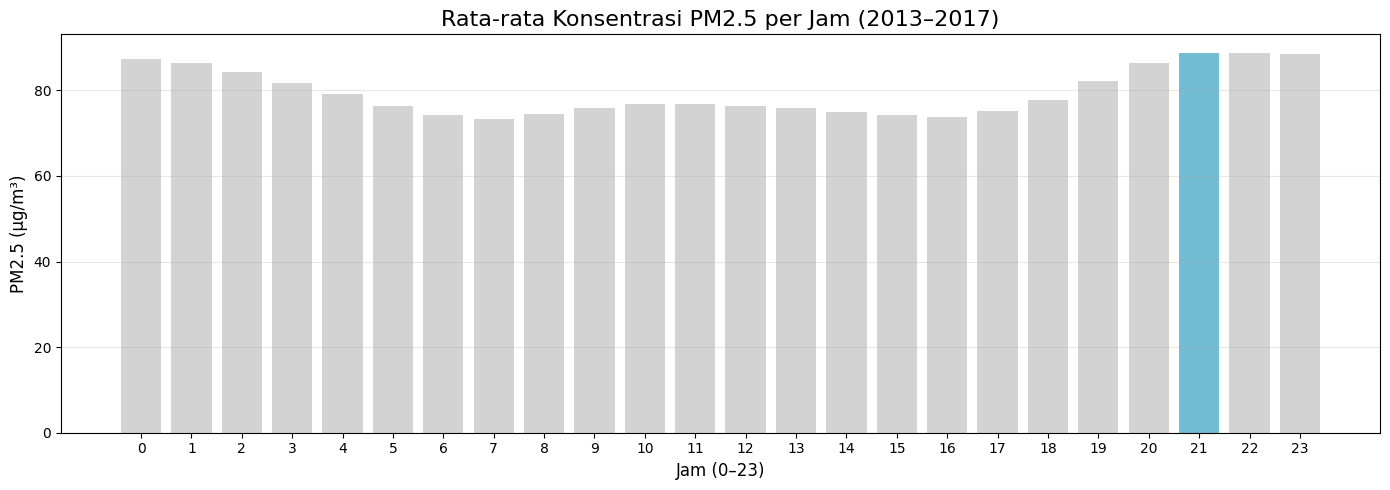

In [35]:
hourly_pm25 = main_df.groupby('hour')['PM2.5'].mean().reset_index()
hourly_pm25.columns = ['hour', 'PM2.5_mean']

max_val = hourly_pm25['PM2.5_mean'].max()
colors = ['#72BCD4' if v == max_val else '#D3D3D3' for v in hourly_pm25['PM2.5_mean']]

plt.figure(figsize=(14, 5))
plt.bar(hourly_pm25['hour'], hourly_pm25['PM2.5_mean'], color=colors)
plt.title('Rata-rata Konsentrasi PM2.5 per Jam (2013–2017)', fontsize=16)
plt.xlabel('Jam (0–23)', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Pertanyaan 4:

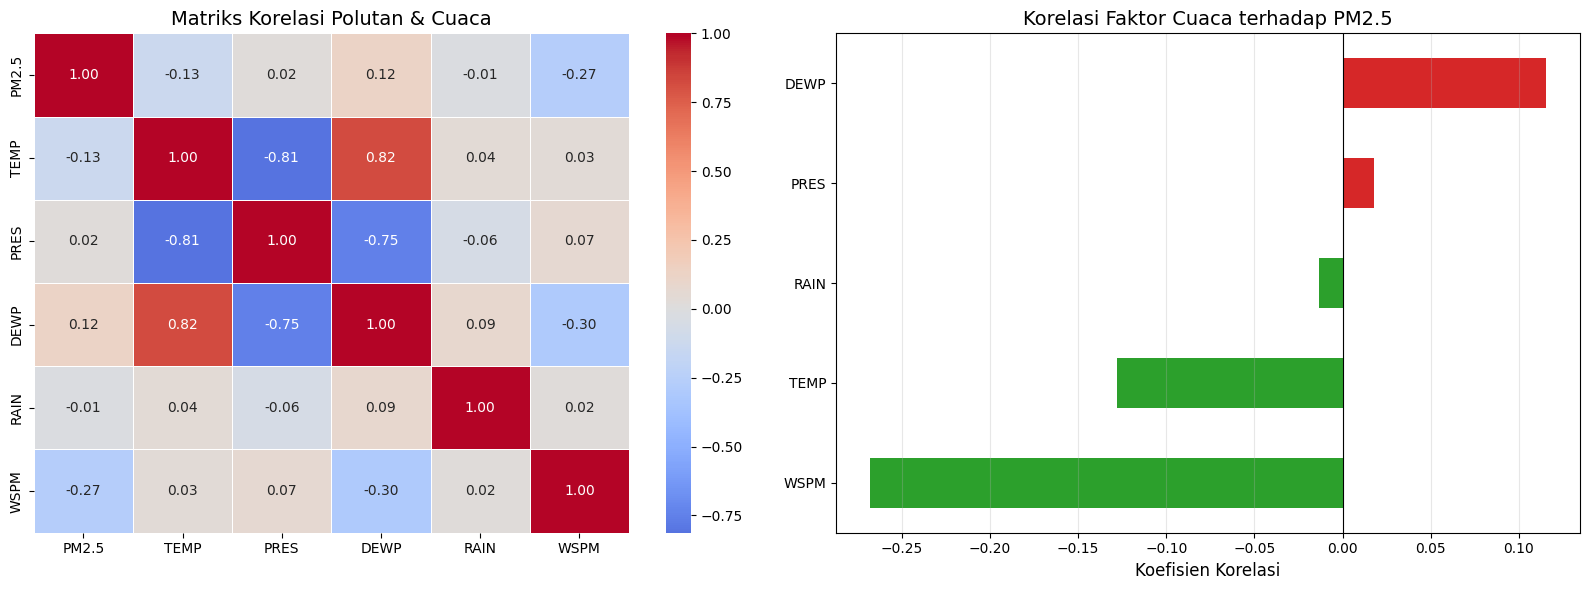

In [36]:
corr_cols = ['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr_matrix = main_df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title('Matriks Korelasi Polutan & Cuaca', fontsize=14)

# Bar chart korelasi terhadap PM2.5
pm25_corr = corr_matrix['PM2.5'].drop('PM2.5').sort_values()
bar_colors = ['#2CA02C' if v < 0 else '#D62728' for v in pm25_corr]
pm25_corr.plot(kind='barh', color=bar_colors, ax=axes[1])
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Korelasi Faktor Cuaca terhadap PM2.5', fontsize=14)
axes[1].set_xlabel('Koefisien Korelasi', fontsize=12)
axes[1].set_ylabel(None)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Grafik tren bulanan memperlihatkan pola berbentuk U terbalik yang
  konsisten setiap tahun, dengan puncak polusi di bulan Desember dan
  lembah di bulan Agustus.
- Perbedaan antar stasiun cukup signifikan (20.3 µg/m³), mengindikasikan
  faktor lokasi seperti kepadatan kendaraan dan industri sangat berpengaruh.
- Pola jam menunjukkan polusi tertinggi terjadi malam hari saat kondisi
  atmosfer lebih stabil dan dispersi polutan berkurang.
- Heatmap korelasi mengkonfirmasi WSPM sebagai faktor cuaca paling
  dominan dalam mempengaruhi konsentrasi PM2.5.

## Analisis Lanjutan (Opsional)

In [37]:
# Koordinat 12 stasiun pemantauan Beijing
station_coords = {
    'Aotizhongxin': (39.9829, 116.3970),
    'Changping':    (40.2149, 116.2310),
    'Dingling':     (40.2900, 116.2200),
    'Dongsi':       (39.9290, 116.4170),
    'Guanyuan':     (39.9290, 116.3390),
    'Gucheng':      (39.9140, 116.1840),
    'Huairou':      (40.3280, 116.6280),
    'Nongzhanguan': (39.9370, 116.4610),
    'Shunyi':       (40.1270, 116.6550),
    'Tiantan':      (39.8860, 116.4070),
    'Wanliu':       (39.9870, 116.2870),
    'Wanshouxigong':(39.8780, 116.3520),
}

# Buat dataframe koordinat + rata-rata PM2.5
station_df = main_df.groupby('location')['PM2.5'].mean().reset_index()
station_df.columns = ['location', 'PM2.5_mean']
station_df['lat'] = station_df['location'].map(lambda x: station_coords[x][0])
station_df['lon'] = station_df['location'].map(lambda x: station_coords[x][1])
station_df['pm25_category'] = station_df['PM2.5_mean'].apply(categorize_pm25)
station_df = station_df.round(2)
station_df

,location,PM2.5_mean,lat,lon,pm25_category
0,Aotizhongxin,83.66,39.98,116.40,Unhealthy
1,Changping,71.77,40.21,116.23,Moderate
2,Dingling,65.43,40.29,116.22,Moderate
3,Dongsi,85.66,39.93,116.42,Unhealthy
4,Guanyuan,82.51,39.93,116.34,Unhealthy
5,Gucheng,83.41,39.91,116.18,Unhealthy
6,Huairou,69.01,40.33,116.63,Moderate
7,Nongzhanguan,84.38,39.94,116.46,Unhealthy
8,Shunyi,78.85,40.13,116.66,Unhealthy
9,Tiantan,81.72,39.89,116.41,Unhealthy


In [38]:
import folium

# Warna berdasarkan kategori
category_color = {
    'Good': 'green',
    'Moderate': 'blue',
    'Unhealthy': 'orange',
    'Very Unhealthy': 'red',
    'Hazardous': 'darkred'
}

# Buat peta
m = folium.Map(
    location=[39.95, 116.38],
    zoom_start=11,
    tiles='CartoDB positron'
)

for _, row in station_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=15,
        color=category_color[row['pm25_category']],
        fill=True,
        fill_color=category_color[row['pm25_category']],
        fill_opacity=0.7,
        popup=folium.Popup(
            f"""
            <b>{row['location']}</b><br>
            PM2.5: {row['PM2.5_mean']} µg/m³<br>
            Kategori: {row['pm25_category']}
            """,
            max_width=200
        ),
        tooltip=f"{row['location']} - {row['PM2.5_mean']} µg/m³"
    ).add_to(m)

m.save('station_map.html')
m

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terdapat pola musiman yang konsisten setiap tahunnya. Konsentrasi PM2.5
mencapai puncak pada bulan Desember (+-104 µg/m³) dan paling rendah pada
bulan Agustus (+-54 µg/m³). Pola ini mengindikasikan pengaruh kuat dari
musim dingin seperti penggunaan pemanas ruangan dan kondisi atmosfer yang
lebih stabil sehingga polutan sulit tersebar.
- **Conclusion pertanyaan 2:** Stasiun Dongsi mencatat rata-rata PM2.5 tertinggi (85.7 µg/m³) sedangkan
stasiun Dingling mencatat yang terendah (65.4 µg/m³) dengan selisih
20.3 µg/m³. Stasiun dengan polusi tinggi umumnya berada di pusat kota
yang padat aktivitas industri dan kendaraan.
- **Conclusion pertanyaan 3:** Konsentrasi PM2.5 mencapai puncak pada jam 21.00 (88.2 µg/m³) dan
berangsur turun hingga siang hari. Hal ini disebabkan oleh kondisi
atmosfer malam hari yang lebih stabil sehingga polutan tidak mudah
tersebar dan menumpuk.
- **Conclusion pertanyaan 4:** Kecepatan angin (WSPM) memiliki korelasi negatif terkuat (-0.27) terhadap
PM2.5, artinya semakin kencang angin maka polutan semakin mudah tersebar
dan konsentrasi PM2.5 menurun. Sebaliknya, titik embun (DEWP) berkorelasi
positif (+0.11) yang mengindikasikan kondisi lembab cenderung menaikkan
konsentrasi PM2.5.

**Rekomendasi Action Item:**

1. **Mendorong penggunaan pemanas ruangan ramah lingkungan:**
   Mengingat konsentrasi PM2.5 mencapai puncak di bulan November–Januari
   yang bertepatan dengan musim dingin, pemerintah dapat mendorong
   masyarakat untuk beralih dari pemanas berbahan bakar fosil (seperti
   batubara) ke pemanas listrik. Transisi ini dapat dilakukan melalui
   subsidi pembelian heater listrik atau insentif pajak bagi rumah tangga
   yang beralih ke energi yang lebih bersih.

2. **Memperbanyak ruang hijau di pusat kota:**
   Stasiun Dongsi dan wilayah sekitarnya yang konsisten mencatat PM2.5
   tertinggi memerlukan intervensi jangka panjang berupa penambahan ruang
   hijau seperti taman kota dan jalur hijau. Tanaman dan pepohonan terbukti
   mampu menyerap partikel polutan secara alami sehingga dapat membantu
   menurunkan konsentrasi PM2.5 secara berkelanjutan di wilayah padat
   aktivitas.

3. **Mendorong penggunaan air purifier di malam hari:**
   Karena PM2.5 mencapai puncaknya pada jam 21.00–23.00 saat masyarakat
   umumnya sudah berada di dalam rumah, penggunaan air purifier di dalam
   ruangan menjadi langkah perlindungan yang paling praktis dan efektif.
   Pemerintah dapat menggalakkan program subsidi atau kemudahan cicilan
   pembelian air purifier, terutama bagi kelompok rentan seperti lansia
   dan anak-anak.

4. **Integrasi data kecepatan angin ke sistem prediksi kualitas udara:**
   Mengingat kecepatan angin (WSPM) memiliki korelasi negatif terkuat
   terhadap PM2.5, data ini dapat dijadikan indikator utama dalam sistem
   prediksi kualitas udara real-time. Ketika kecepatan angin diprediksi
   rendah, sistem dapat secara otomatis mengirimkan notifikasi peringatan
   kepada masyarakat agar membatasi aktivitas luar ruangan dan meningkatkan
   kewaspadaan terhadap paparan polutan.